# RF-Based Drone Signal Detection

**Module 20 Initial Report and Exploratory Data Analysis**

This project asks: **Can a supervised machine-learning model detect drone-associated radio-frequency (RF) activity while keeping the false-positive rate at or below 5%?**

The original Module 16 proposal named CardRF, but that dataset was not accessible. The project therefore pivots to the public [Noisy Drone RF Signal Classification dataset](https://www.kaggle.com/datasets/sgluege/noisy-drone-rf-signal-classification). The research question and binary-classification design remain unchanged; only the primary data source changes.

**Target**
- `1`: drone-associated RF signal
- `0`: RF background/noise

**Why it matters:** RF detection can complement visual detection when drones are distant, obscured, or operating in low light. A useful detector must balance drone recall with a low false-alarm rate.


## 1. Setup and reproducibility

The notebook uses a manifest to keep data lineage explicit and reads saved experiment artifacts so the documented results exactly match the completed capstone run. Paths are resolved from either the repository root or the `notebooks/` directory.


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from rf_drone_detection.config import PipelineConfig
from rf_drone_detection.features import load_iq_or_vector, log_spectrogram
from rf_drone_detection.manifest import load_manifest

sns.set_theme(style="whitegrid", context="notebook")
config = PipelineConfig()
manifest_path = PROJECT_ROOT / "data" / "interim" / "manifest.csv"
artifact_dir = PROJECT_ROOT / "reports" / "artifacts" / "noisy_drone_rf"

required = [manifest_path, artifact_dir / "model_comparison.csv", artifact_dir / "test_metrics.json"]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required capstone artifact(s):\n" + "\n".join(missing))

print(f"Project root: {PROJECT_ROOT}")
print(f"Manifest: {manifest_path}")


Project root: /Users/privateaya_1/Documents/berkeley_capstone
Manifest: /Users/privateaya_1/Documents/berkeley_capstone/data/interim/manifest.csv


## 2. Data source and structure

The primary dataset contains RF in-phase/quadrature (I/Q) samples across seven original labels: six drone/controller classes and one noise class. The full downloaded archive contains 98,705 examples with SNR values from -20 dB to 30 dB. To keep the capstone run computationally bounded and reproducible, 1,000 observations per original class were selected (7,000 total).

The manifest records one row per model input with its source, recording identifier, local path, original class, binary label, split, and signal-to-noise ratio (SNR). `Noise` maps to 0; all controller/drone-associated classes map to 1.

A small DroneRF subset is retained only as an external domain-shift check. It is not mixed into primary training or test data because its collection and representation differ.


In [2]:
manifest = load_manifest(manifest_path)
display(manifest.head())

structure = pd.DataFrame({
    "column": manifest.columns,
    "dtype": manifest.dtypes.astype(str).values,
    "missing_values": manifest.isna().sum().values,
    "unique_values": [manifest[c].nunique() for c in manifest.columns],
})
display(structure)
print(f"Rows: {len(manifest):,}")
print(f"Duplicate sample IDs: {manifest['sample_id'].duplicated().sum()}")
print(f"Missing referenced signal files: {(~manifest['path'].map(lambda p: Path(p).exists())).sum()}")


,sample_id,source,recording_id,path,original_label,binary_label,split,snr
0,noisy_drone_rf_000000,noisy_drone_rf,noisy_drone_rf_000000,/Users/privateaya_1/Documents/berkeley_capston...,DJI,1,train,4
1,noisy_drone_rf_000001,noisy_drone_rf,noisy_drone_rf_000001,/Users/privateaya_1/Documents/berkeley_capston...,DJI,1,train,8
2,noisy_drone_rf_000002,noisy_drone_rf,noisy_drone_rf_000002,/Users/privateaya_1/Documents/berkeley_capston...,DJI,1,train,-14
3,noisy_drone_rf_000003,noisy_drone_rf,noisy_drone_rf_000003,/Users/privateaya_1/Documents/berkeley_capston...,DJI,1,train,26
4,noisy_drone_rf_000004,noisy_drone_rf,noisy_drone_rf_000004,/Users/privateaya_1/Documents/berkeley_capston...,DJI,1,train,6


,column,dtype,missing_values,unique_values
0,sample_id,object,0,7000
1,source,object,0,1
2,recording_id,object,0,7000
3,path,object,0,7000
4,original_label,object,0,7
5,binary_label,int64,0,2
6,split,object,0,3
7,snr,int64,0,26


Rows: 7,000
Duplicate sample IDs: 0
Missing referenced signal files: 0


## 3. Exploratory data analysis

The selected subset is balanced across the seven original labels. After conversion to the binary target, the positive class is intentionally larger because six of the seven original labels represent drone-associated activity. Stratified train/validation/test splits preserve that composition.


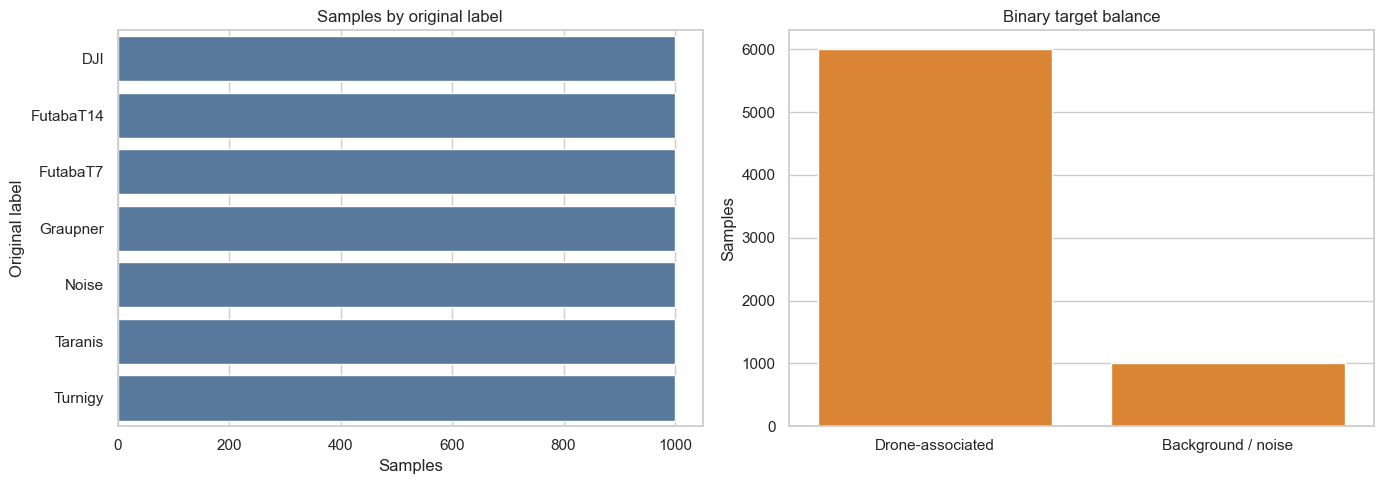

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = sorted(manifest["original_label"].unique())
sns.countplot(data=manifest, y="original_label", order=order, color="#4C78A8", ax=axes[0])
axes[0].set(title="Samples by original label", xlabel="Samples", ylabel="Original label")

binary_names = manifest["binary_label"].map({0: "Background / noise", 1: "Drone-associated"})
sns.countplot(x=binary_names, color="#F58518", ax=axes[1])
axes[1].set(title="Binary target balance", xlabel="", ylabel="Samples")
plt.tight_layout()
plt.show()


binary_label,Background / noise,Drone-associated,All
split,,,
test,200,1200,1400
train,600,3600,4200
validation,200,1200,1400
All,1000,6000,7000


Recording IDs assigned to more than one split: 0


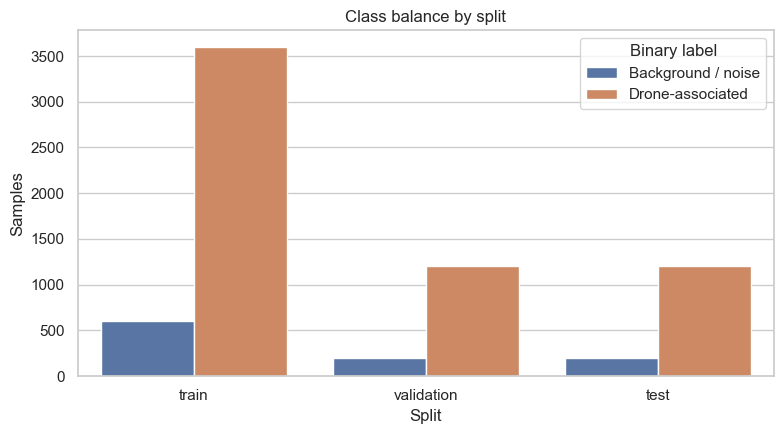

In [4]:
split_table = pd.crosstab(
    manifest["split"],
    manifest["binary_label"].map({0: "Background / noise", 1: "Drone-associated"}),
    margins=True,
)
display(split_table)

recording_split_counts = manifest.groupby("recording_id")["split"].nunique()
print(f"Recording IDs assigned to more than one split: {(recording_split_counts > 1).sum()}")

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.countplot(data=manifest, x="split", hue="binary_label", order=["train", "validation", "test"], ax=ax)
ax.set(title="Class balance by split", xlabel="Split", ylabel="Samples")
ax.legend(title="Binary label", labels=["Background / noise", "Drone-associated"])
plt.tight_layout()
plt.show()


### Signal-to-noise ratio

SNR measures signal strength relative to background noise. Lower values represent harder detection conditions. The dataset spans -20 to 30 dB, allowing performance to be evaluated across easy and difficult RF conditions.


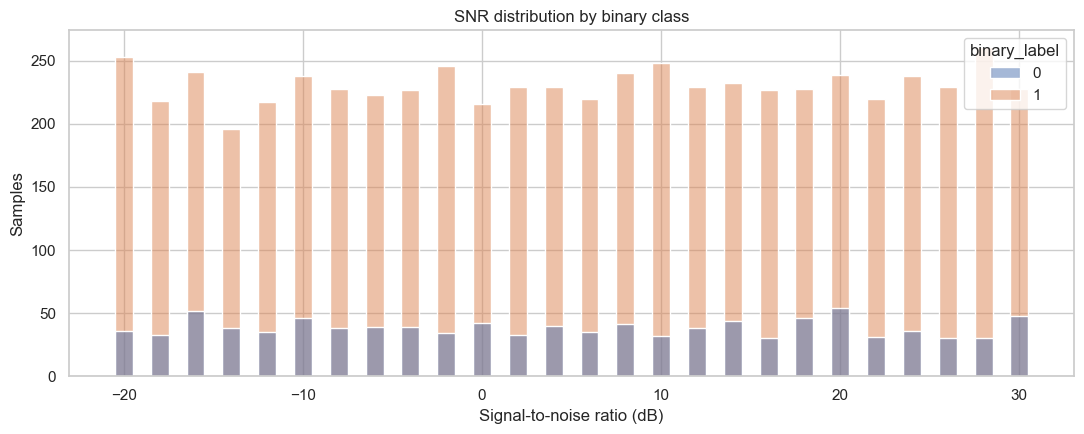

,count,min,median,max
binary_label,,,,
Background / noise,1000,-20,4.0,30
Drone-associated,6000,-20,6.0,30


In [5]:
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.histplot(data=manifest, x="snr", hue="binary_label", multiple="layer", discrete=True, ax=ax)
ax.set(title="SNR distribution by binary class", xlabel="Signal-to-noise ratio (dB)", ylabel="Samples")
plt.tight_layout()
plt.show()

display(manifest.groupby("binary_label")["snr"].agg(["count", "min", "median", "max"]).rename(index={0:"Background / noise", 1:"Drone-associated"}))


### Representative signal transformation

Raw I/Q values are converted to normalized log-spectrograms. A spectrogram represents frequency content over time and makes compact spectral features available to classical models.


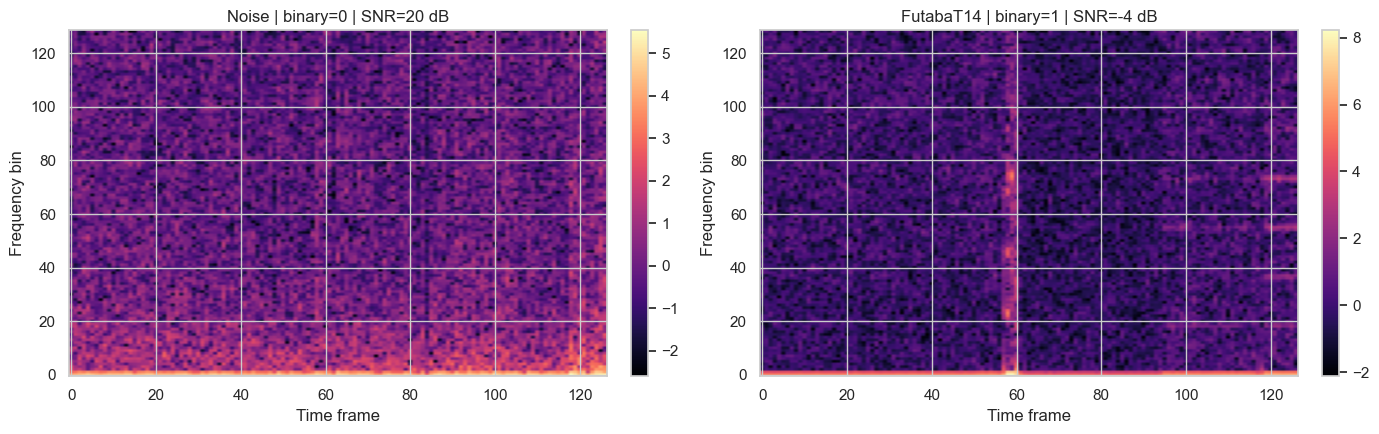

In [6]:
examples = pd.concat([
    manifest[manifest["binary_label"].eq(0)].sample(1, random_state=42),
    manifest[manifest["binary_label"].eq(1)].sample(1, random_state=42),
])
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, (_, row) in zip(axes, examples.iterrows()):
    values = load_iq_or_vector(row["path"])
    spec = log_spectrogram(values, config=config)
    image = ax.imshow(spec, origin="lower", aspect="auto", cmap="magma")
    ax.set_title(f"{row['original_label']} | binary={row['binary_label']} | SNR={row['snr']} dB")
    ax.set_xlabel("Time frame")
    ax.set_ylabel("Frequency bin")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 4. Data preparation

The preprocessing workflow is:

1. Read I/Q arrays from the downloaded PyTorch archive and save the selected observations as NumPy files.
2. Validate required manifest fields, labels, file paths, and split assignments.
3. Keep each `recording_id` in exactly one split to reduce leakage risk.
4. Convert each signal to a normalized log-spectrogram.
5. Extract ten compact spectral summary features for classical baselines.
6. Train on the training split, choose model and threshold on validation data, and evaluate once on held-out test data.

No target encoding is needed beyond mapping `Noise → 0` and all six drone/controller labels `→ 1`. The signal arrays are numerical and contain no tabular missing values. Normalization occurs at the spectrogram level.


## 5. Modeling and validation

Two supervised classifiers were compared:

- **Logistic regression:** interpretable linear baseline with regularization.
- **Random forest:** nonlinear tree ensemble that can model feature interactions.

The operating threshold is not fixed at 0.5. For each model, validation data selects the threshold that maximizes recall while requiring false-positive rate (FPR) ≤ 5%. This reflects the practical need to detect as many drone signals as possible without producing excessive false alarms.


In [7]:
model_comparison = pd.read_csv(artifact_dir / "model_comparison.csv")
display(model_comparison.style.format({
    "validation_threshold": "{:.3f}",
    "validation_recall": "{:.3f}",
    "validation_precision": "{:.3f}",
    "validation_fpr": "{:.3f}",
    "validation_f1": "{:.3f}",
    "validation_pr_auc": "{:.3f}",
}))

selected = model_comparison.sort_values(
    ["validation_recall", "validation_pr_auc", "validation_f1"], ascending=False
).iloc[0]
print(f"Selected model: {selected['model']}")
print(f"Validation-selected threshold: {selected['validation_threshold']:.3f}")


,model,validation_threshold,validation_recall,validation_precision,validation_fpr,validation_f1,validation_pr_auc
0,logistic_regression,0.530,0.673,0.988,0.050,0.801,0.981
1,random_forest,0.952,0.666,0.988,0.050,0.795,0.985


Selected model: logistic_regression
Validation-selected threshold: 0.530


## 6. Held-out test results

The selected logistic regression model met the false-positive constraint on the held-out test set. Precision and PR-AUC were high, but overall recall was 64.5%, showing a meaningful miss rate that requires investigation by SNR.


,metric,value
0,threshold,0.530
1,recall,0.645
2,precision,0.991
3,f1,0.781
4,fpr,0.035
5,pr_auc,0.984
6,roc_auc,0.910
7,true_negative,193.000
8,false_positive,7.000
9,false_negative,426.000


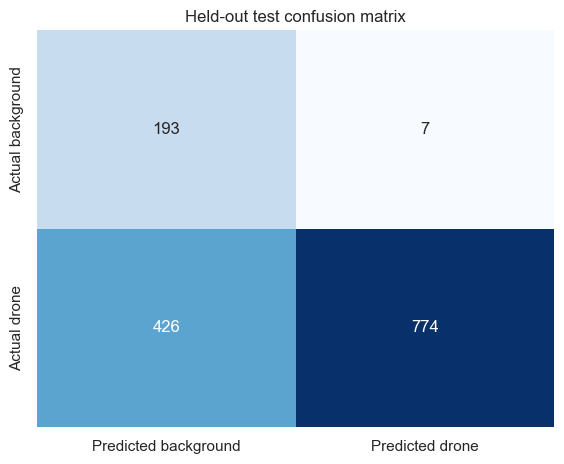

In [8]:
with open(artifact_dir / "test_metrics.json") as f:
    test_metrics = json.load(f)

metric_order = ["threshold", "recall", "precision", "f1", "fpr", "pr_auc", "roc_auc",
                "true_negative", "false_positive", "false_negative", "true_positive"]
metrics_display = pd.DataFrame({
    "metric": metric_order,
    "value": [test_metrics[k] for k in metric_order],
})
display(metrics_display.style.format({"value": "{:.3f}"}))

cm = np.array([
    [test_metrics["true_negative"], test_metrics["false_positive"]],
    [test_metrics["false_negative"], test_metrics["true_positive"]],
])
fig, ax = plt.subplots(figsize=(5.8, 4.8))
sns.heatmap(cm, annot=True, fmt=".0f", cmap="Blues", cbar=False,
            xticklabels=["Predicted background", "Predicted drone"],
            yticklabels=["Actual background", "Actual drone"], ax=ax)
ax.set_title("Held-out test confusion matrix")
plt.tight_layout()
plt.show()


### Performance by SNR

The aggregate result hides the strongest finding: performance depends heavily on signal quality. Recall is poor at strongly negative SNR and rises sharply near 0 dB. At 6 dB and above, recall is generally near 1.0 in this test sample.


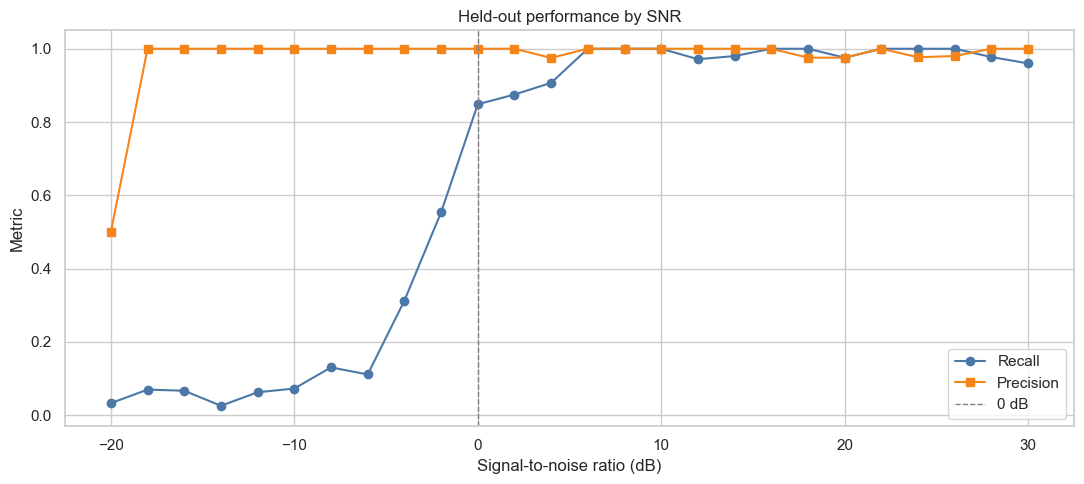

,snr,rows,recall,precision,fpr
0,-20,69,0.033,0.500,0.250
1,-18,49,0.070,1.000,0.000
2,-16,55,0.067,1.000,0.000
3,-14,49,0.026,1.000,0.000
4,-12,40,0.062,1.000,0.000
5,-10,67,0.073,1.000,0.000
6,-8,59,0.130,1.000,0.000
7,-6,63,0.111,1.000,0.000
8,-4,53,0.312,1.000,0.000
9,-2,61,0.554,1.000,0.000


In [9]:
snr_metrics = pd.read_csv(artifact_dir / "metrics_by_snr.csv").sort_values("snr")
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(snr_metrics["snr"], snr_metrics["recall"], marker="o", label="Recall", color="#4C78A8")
ax.plot(snr_metrics["snr"], snr_metrics["precision"], marker="s", label="Precision", color="#F58518")
ax.axvline(0, color="gray", linestyle="--", linewidth=1, label="0 dB")
ax.set(title="Held-out performance by SNR", xlabel="Signal-to-noise ratio (dB)", ylabel="Metric", ylim=(-0.03, 1.05))
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

display(snr_metrics[["snr", "rows", "recall", "precision", "fpr"]].style.format({
    "recall": "{:.3f}", "precision": "{:.3f}", "fpr": "{:.3f}"
}))


## 7. Conclusions, limitations, and next steps

**Answer to the research question:** Yes, the model can identify drone-associated RF activity under the measured conditions while holding test FPR to 3.5%. However, the 64.5% overall recall is not sufficient for a high-stakes operational detector. The model is reliable mainly at moderate-to-high SNR and misses many weak signals.

**Key findings**
- Logistic regression slightly exceeded random forest validation recall under the 5% FPR constraint.
- Test precision was 99.1%, so positive alerts were usually correct in this held-out sample.
- Detection quality changed dramatically with SNR; low-SNR signals caused most misses.
- The CardRF-to-Noisy-Drone-RF pivot preserved the binary research question and made the analysis reproducible with an accessible public dataset.

**Limitations**
- The 7,000-sample capstone subset is balanced by original label and does not reflect real-world class prevalence.
- Public laboratory data may not represent unseen hardware, locations, interference, frequencies, or RF-silent/autonomous drones.
- The small DroneRF external check showed poor transfer at the selected threshold; its sample is too small for a definitive benchmark but signals domain shift.
- A random split by individual examples can still overstate generalization if collection sessions share hidden similarities. The manifest enforces unique recording identifiers, but richer session metadata would strengthen leakage controls.

**Next steps**
1. Expand external testing with a larger, harmonized DroneRF subset.
2. Add a compact CNN and compare it under the same validation FPR constraint.
3. Improve low-SNR robustness using augmentation, denoising, class/SNR weighting, or specialized features.
4. Calibrate probabilities and test operating thresholds across deployment-like RF environments.

This is an academic research prototype for defensive RF awareness, not a deployed safety or enforcement system.
